
=== Scheme 1 Metrics by Volume Bin ===
volume_bin    N    Brier  ECE (quantile bins)      AUC
       <1k  418 0.095695             0.083741 0.934135
    1k-10k 1989 0.081317             0.036531 0.925639
  10k-100k 4582 0.078632             0.012763 0.948757
   100k-1m 1626 0.047835             0.006256 0.979642
      >=1m  406 0.002114             0.004969 0.999963


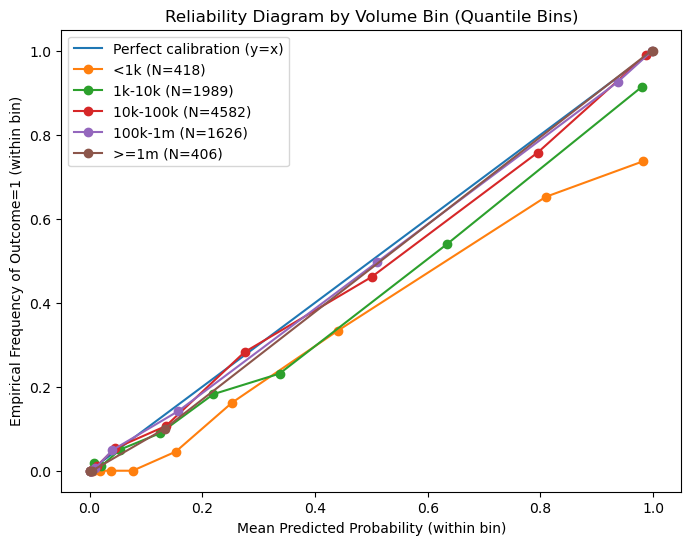


=== Bootstrap 95% CI by Volume Bin (n_boot=1000) ===
volume_bin    N    Brier       Brier_95CI      ECE         ECE_95CI      AUC         AUC_95CI
       <1k  418 0.095695 [0.0764, 0.1177] 0.083741 [0.0610, 0.1141] 0.934135 [0.9110, 0.9558]
    1k-10k 1989 0.081317 [0.0732, 0.0891] 0.036531 [0.0266, 0.0498] 0.925639 [0.9124, 0.9386]
  10k-100k 4582 0.078632 [0.0741, 0.0835] 0.012763 [0.0079, 0.0209] 0.948757 [0.9428, 0.9541]
   100k-1m 1626 0.047835 [0.0406, 0.0549] 0.006256 [0.0053, 0.0192] 0.979642 [0.9738, 0.9849]
      >=1m  406 0.002114 [0.0004, 0.0049] 0.004969 [0.0018, 0.0103] 0.999963 [0.9998, 1.0000]


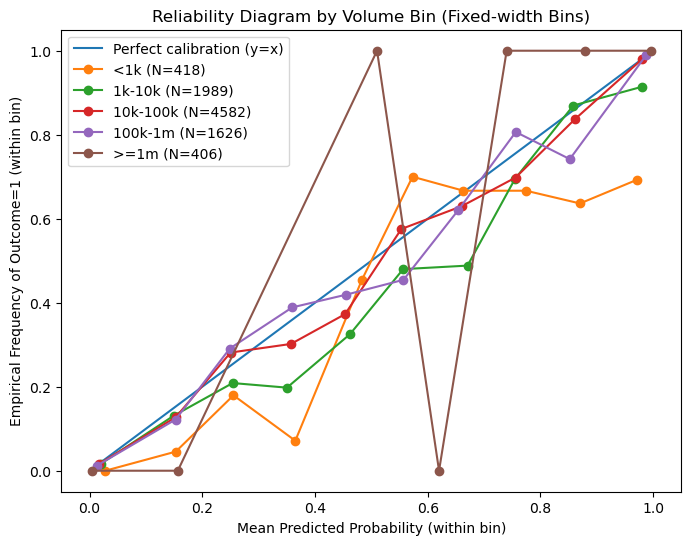


=== Outcome balance by Volume Bin ===
            count      mean  ones  zeros
volume_bin                              
<1k           418  0.191388    80    338
1k-10k       1989  0.203117   404   1585
10k-100k     4582  0.266041  1219   3363
100k-1m      1626  0.261993   426   1200
>=1m          406  0.209360    85    321


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# =========================
# 0) Load + clean
# =========================
CSV_PATH = r"D:\Cornell University\Term 3\SYSEN 5380\paper\polymarket_markets.csv"

df = pd.read_csv(CSV_PATH)

needed = ["pred_prob_day_minus_1", "final_outcome_yes", "volume"]
df = df.dropna(subset=needed).copy()

df["pred_prob_day_minus_1"] = df["pred_prob_day_minus_1"].astype(float).clip(0, 1)
df["final_outcome_yes"] = df["final_outcome_yes"].astype(int)
df["volume"] = df["volume"].astype(float)

# =========================
# 1) Volume bins (outer stratification)
# =========================
volume_bins = [-np.inf, 1000, 10000, 100000, 1000000, np.inf]
volume_labels = ["<1k", "1k-10k", "10k-100k", "100k-1m", ">=1m"]

df["volume_bin"] = pd.cut(
    df["volume"],
    bins=volume_bins,
    labels=volume_labels,
    right=False
)

# =========================
# 2) ECE (quantile bins within each volume stratum)
# =========================
def ece_quantile(p: np.ndarray, y: np.ndarray, n_bins: int = 10) -> float:
    """
    ECE using equal-frequency (quantile) bins.
    Returns weighted avg |empirical_freq - mean_pred| across bins.
    """
    p = np.asarray(p)
    y = np.asarray(y)

    bins = pd.qcut(p, q=n_bins, duplicates="drop")
    tmp = pd.DataFrame({"p": p, "y": y, "bin": bins})
    g = tmp.groupby("bin", observed=True)

    n = g.size()
    mean_pred = g["p"].mean()
    emp_freq = g["y"].mean()

    ece = (n / len(tmp) * (emp_freq - mean_pred).abs()).sum()
    return float(ece)

# =========================
# 3) Calibration table for plotting (quantile bins)
# =========================
def calibration_table_quantile_bins(p: np.ndarray, y: np.ndarray, n_bins: int = 10) -> pd.DataFrame:
    """
    Returns a table with n, mean_pred, empirical_freq for a reliability diagram.
    Uses equal-frequency (quantile) bins within the given stratum.
    """
    p = np.asarray(p)
    y = np.asarray(y)

    bins = pd.qcut(p, q=n_bins, duplicates="drop")
    tmp = pd.DataFrame({"p": p, "y": y, "bin": bins})
    g = tmp.groupby("bin", observed=True)

    tab = pd.DataFrame({
        "n": g.size(),
        "mean_pred": g["p"].mean(),
        "empirical_freq": g["y"].mean()
    }).reset_index(drop=True)

    return tab.sort_values("mean_pred")

# =========================
# 4) Compute metrics by volume bin: N, Brier, ECE, AUC
# =========================
rows = []
for vb in volume_labels:
    sub = df[df["volume_bin"] == vb]
    if len(sub) == 0:
        continue

    p = sub["pred_prob_day_minus_1"].to_numpy()
    y = sub["final_outcome_yes"].to_numpy()

    brier = float(np.mean((p - y) ** 2))
    ece = ece_quantile(p, y, n_bins=10)

    # AUC requires both classes present
    if len(np.unique(y)) < 2:
        auc = np.nan
    else:
        auc = float(roc_auc_score(y, p))

    rows.append({
        "volume_bin": vb,
        "N": int(len(sub)),
        "Brier": brier,
        "ECE (quantile bins)": ece,
        "AUC": auc
    })

metrics = pd.DataFrame(rows).sort_values(
    "volume_bin",
    key=lambda s: s.map({lab: i for i, lab in enumerate(volume_labels)})
)

print("\n=== Scheme 1 Metrics by Volume Bin ===")
print(metrics.to_string(index=False))

# =========================
# 5) Plot reliability diagram(s) by volume bin (quantile bins)  [MAIN FIGURE]
# =========================
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], label="Perfect calibration (y=x)")

for vb in volume_labels:
    sub = df[df["volume_bin"] == vb]
    if len(sub) == 0:
        continue

    p = sub["pred_prob_day_minus_1"].to_numpy()
    y = sub["final_outcome_yes"].to_numpy()

    tab = calibration_table_quantile_bins(p, y, n_bins=10)

    plt.plot(
        tab["mean_pred"],
        tab["empirical_freq"],
        marker="o",
        linestyle="-",
        label=f"{vb} (N={len(sub)})"
    )

plt.title("Reliability Diagram by Volume Bin (Quantile Bins)")
plt.xlabel("Mean Predicted Probability (within bin)")
plt.ylabel("Empirical Frequency of Outcome=1 (within bin)")
plt.legend()
plt.show()

# =========================
# 6) Bootstrap 95% CI for Brier / ECE / AUC by volume bin  [MAIN TABLE]
# =========================
def brier_score(p, y):
    return float(np.mean((p - y) ** 2))

def safe_auc(p, y):
    if len(np.unique(y)) < 2:
        return np.nan
    return float(roc_auc_score(y, p))

def bootstrap_ci(sub_df, metric_fn, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(sub_df)
    idx = np.arange(n)

    stats = []
    for _ in range(n_boot):
        sample_idx = rng.choice(idx, size=n, replace=True)
        samp = sub_df.iloc[sample_idx]
        p = samp["pred_prob_day_minus_1"].to_numpy()
        y = samp["final_outcome_yes"].to_numpy()
        stats.append(metric_fn(p, y))

    stats = np.array(stats, dtype=float)
    stats = stats[~np.isnan(stats)]
    if len(stats) == 0:
        return (np.nan, np.nan, np.nan)

    return (float(np.mean(stats)),
            float(np.quantile(stats, 0.025)),
            float(np.quantile(stats, 0.975)))

volume_order = ["<1k", "1k-10k", "10k-100k", "100k-1m", ">=1m"]

ci_rows = []
for vb in volume_order:
    sub = df[df["volume_bin"] == vb].copy()
    if len(sub) == 0:
        continue

    p0 = sub["pred_prob_day_minus_1"].to_numpy()
    y0 = sub["final_outcome_yes"].to_numpy()

    # Point estimates (from full sample)
    b0 = brier_score(p0, y0)
    e0 = ece_quantile(p0, y0, n_bins=10)
    a0 = safe_auc(p0, y0)

    # Bootstrap CIs
    _, b_lo, b_hi = bootstrap_ci(sub, brier_score, n_boot=1000, seed=42)
    _, e_lo, e_hi = bootstrap_ci(sub, lambda p, y: ece_quantile(p, y, n_bins=10), n_boot=1000, seed=42)
    _, a_lo, a_hi = bootstrap_ci(sub, safe_auc, n_boot=1000, seed=42)

    ci_rows.append({
        "volume_bin": vb,
        "N": int(len(sub)),
        "Brier": b0,
        "Brier_95CI": f"[{b_lo:.4f}, {b_hi:.4f}]",
        "ECE": e0,
        "ECE_95CI": f"[{e_lo:.4f}, {e_hi:.4f}]",
        "AUC": a0,
        "AUC_95CI": (f"[{a_lo:.4f}, {a_hi:.4f}]" if not np.isnan(a0) else "NA")
    })

ci_table = pd.DataFrame(ci_rows)
print("\n=== Bootstrap 95% CI by Volume Bin (n_boot=1000) ===")
print(ci_table.to_string(index=False))

# =========================
# 7) Robustness / Appendix: Reliability diagram with fixed-width bins  [APPENDIX FIGURE]
# =========================
def calibration_table_fixed_bins(p: np.ndarray, y: np.ndarray, n_bins: int = 10) -> pd.DataFrame:
    p = np.asarray(p)
    y = np.asarray(y)

    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.digitize(p, edges, right=True) - 1
    idx = np.clip(idx, 0, n_bins - 1)

    out = []
    for b in range(n_bins):
        mask = (idx == b)
        n = int(mask.sum())
        if n == 0:
            continue
        out.append({
            "bin_left": edges[b],
            "bin_right": edges[b + 1],
            "n": n,
            "mean_pred": float(p[mask].mean()),
            "empirical_freq": float(y[mask].mean()),
        })
    return pd.DataFrame(out).sort_values("mean_pred")

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], label="Perfect calibration (y=x)")

for vb in volume_order:
    sub = df[df["volume_bin"] == vb]
    if len(sub) == 0:
        continue

    p = sub["pred_prob_day_minus_1"].to_numpy()
    y = sub["final_outcome_yes"].to_numpy()

    tab = calibration_table_fixed_bins(p, y, n_bins=10)

    plt.plot(
        tab["mean_pred"],
        tab["empirical_freq"],
        marker="o",
        linestyle="-",
        label=f"{vb} (N={len(sub)})"
    )

plt.title("Reliability Diagram by Volume Bin (Fixed-width Bins)")
plt.xlabel("Mean Predicted Probability (within bin)")
plt.ylabel("Empirical Frequency of Outcome=1 (within bin)")
plt.legend()
plt.show()

# =========================
# 8) Outcome balance by volume bin (EXACTLY as you requested)
# =========================
balance = df.groupby("volume_bin", observed=True)["final_outcome_yes"].agg(["count", "mean"])
balance["ones"] = df.groupby("volume_bin", observed=True)["final_outcome_yes"].sum().astype(int)
balance["zeros"] = (balance["count"] - balance["ones"]).astype(int)

print("\n=== Outcome balance by Volume Bin ===")
print(balance)